RandomForest Test Accuracy: 1.0000

Classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Confusion matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


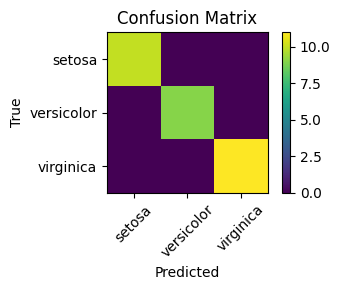

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# Split
iris = load_iris(as_frame=True)
X = iris.data
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,)
# Train
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)
# Predict & evaluate
y_pred = rf_classifier.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f'RandomForest Test Accuracy: {acc:.4f}\n')
print('Classification report:')
print(classification_report(y_test, y_pred, target_names=iris.target_names))
# Confusion matrix (plot)
cm = confusion_matrix(y_test, y_pred)
print('Confusion matrix:\n', cm)
import matplotlib.pyplot as plt
plt.figure(figsize=(4,3))
plt.imshow(cm, interpolation='nearest')
plt.title('Confusion Matrix')
plt.colorbar()
plt.xticks(range(len(iris.target_names)), iris.target_names, rotation=45)
plt.yticks(range(len(iris.target_names)), iris.target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# Load data
iris = load_iris()
X, y = iris.data, iris.target

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [11]:
import os,joblib,pickle
from sklearn.metrics import accuracy_score

#Saving using pickle file 
with open("models/iris_model.pickle","wb") as f:
    pickle.dump(rf,f)
y_pred = rf.predict(X_test)
print(accuracy_score(y_test,y_pred))

1.0


In [16]:
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import pickle
import json

# --------------------------------------------------
# Page Configuration
# --------------------------------------------------

st.set_page_config(
    page_title="Iris Flower Classifier",
    page_icon="🌸",
    layout="wide"
)

# --------------------------------------------------
# Custom CSS
# --------------------------------------------------

st.markdown("""
<style>
.main-header {
    text-align: center;
    color: #6a0dad;
    font-size: 3rem;
    margin-bottom: 20px;
}

.prediction-card {
    padding: 20px;
    border-radius: 10px;
    background-color: #f8f9fa;
    border-left: 5px solid #6a0dad;
}
</style>
""", unsafe_allow_html=True)

# --------------------------------------------------
# Load Resources
# --------------------------------------------------

@st.cache_resource
def load_model(model_format):
    try:
        if model_format == "joblib":
            return joblib.load("models/iris_model.joblib")

        with open("models/iris_model.pickle", "rb") as f:
            return pickle.load(f)

    except Exception as e:
        st.error(f"Error loading model: {e}")
        return None


@st.cache_data
def load_model_info():
    try:
        with open("models/model_info.json", "r") as f:
            return json.load(f)
    except:
        return {
            "model_type": "Random Forest",
            "accuracy": 0.96,
            "target_names": [
                "setosa",
                "versicolor",
                "virginica"
            ]
        }


@st.cache_data
def load_feature_ranges():
    try:
        with open("models/feature_ranges.json", "r") as f:
            return json.load(f)
    except:
        return {
            "sepal_length": {"min": 4.0, "max": 8.0, "default": 5.8},
            "sepal_width": {"min": 2.0, "max": 4.5, "default": 3.0},
            "petal_length": {"min": 1.0, "max": 7.0, "default": 4.0},
            "petal_width": {"min": 0.1, "max": 2.5, "default": 1.2},
        }


# --------------------------------------------------
# Sidebar
# --------------------------------------------------

with st.sidebar:
    st.title("⚙️ Settings")

    model_format = st.radio(
        "Select Model Format",
        ["joblib", "pickle"]
    )

    st.divider()

    st.subheader("ℹ️ Model Information")

model_info = load_model_info()
feature_ranges = load_feature_ranges()
model = load_model(model_format)

if model_info:
    with st.sidebar:
        st.write(
            f"**Type:** {model_info.get('model_type', 'Random Forest')}"
        )
        st.write(
            f"**Accuracy:** {model_info.get('accuracy', 0.96):.1%}"
        )

# --------------------------------------------------
# Main Title
# --------------------------------------------------

st.markdown(
    '<h1 class="main-header">🌸 Iris Flower Classification</h1>',
    unsafe_allow_html=True
)

st.write(
    """
    Predict the species of an Iris flower using a trained
    machine learning model.

    Adjust the flower measurements below and click
    **Predict Species**.
    """
)

# --------------------------------------------------
# Layout
# --------------------------------------------------

col1, col2 = st.columns([2, 1])

with col1:

    st.subheader("📝 Input Features")

    sepal_length = st.slider(
        "Sepal Length (cm)",
        float(feature_ranges["sepal_length"]["min"]),
        float(feature_ranges["sepal_length"]["max"]),
        float(feature_ranges["sepal_length"]["default"]),
        0.1
    )

    sepal_width = st.slider(
        "Sepal Width (cm)",
        float(feature_ranges["sepal_width"]["min"]),
        float(feature_ranges["sepal_width"]["max"]),
        float(feature_ranges["sepal_width"]["default"]),
        0.1
    )

    petal_length = st.slider(
        "Petal Length (cm)",
        float(feature_ranges["petal_length"]["min"]),
        float(feature_ranges["petal_length"]["max"]),
        float(feature_ranges["petal_length"]["default"]),
        0.1
    )

    petal_width = st.slider(
        "Petal Width (cm)",
        float(feature_ranges["petal_width"]["min"]),
        float(feature_ranges["petal_width"]["max"]),
        float(feature_ranges["petal_width"]["default"]),
        0.1
    )

with col2:

    st.subheader("📊 Current Values")

    features_df = pd.DataFrame({
        "Feature": [
            "Sepal Length",
            "Sepal Width",
            "Petal Length",
            "Petal Width"
        ],
        "Value": [
            sepal_length,
            sepal_width,
            petal_length,
            petal_width
        ]
    })

    st.dataframe(
        features_df,
        use_container_width=True,
        hide_index=True
    )

# --------------------------------------------------
# Prediction
# --------------------------------------------------

input_features = np.array([
    [
        sepal_length,
        sepal_width,
        petal_length,
        petal_width
    ]
])

if st.button(
    "🎯 Predict Species",
    type="primary",
    use_container_width=True
):

    if model is None:
        st.error("Model could not be loaded.")
        st.stop()

    try:
        prediction = model.predict(input_features)[0]

        if hasattr(model, "predict_proba"):
            probabilities = model.predict_proba(input_features)[0]
        else:
            probabilities = None

        target_names = model_info.get(
            "target_names",
            ["setosa", "versicolor", "virginica"]
        )

        predicted_species = target_names[prediction]

        st.markdown(
            f"""
            <div class="prediction-card">
                <h2>🌸 Prediction Result</h2>
                <h3>{predicted_species}</h3>
            </div>
            """,
            unsafe_allow_html=True
        )

        if probabilities is not None:

            st.subheader("📈 Confidence Scores")

            for species, prob in zip(target_names, probabilities):
                st.write(f"**{species}**")
                st.progress(float(prob))
                st.write(f"{prob:.2%}")

    except Exception as e:
        st.error(f"Prediction Error: {e}")

# --------------------------------------------------
# Dataset Information
# --------------------------------------------------

with st.expander("📚 About the Iris Dataset"):

    st.markdown("""
### Dataset Overview

The Iris dataset contains:

- 150 flower samples
- 3 species
- 4 numerical features

### Species

- Iris Setosa
- Iris Versicolor
- Iris Virginica

### Features

1. Sepal Length
2. Sepal Width
3. Petal Length
4. Petal Width

This is one of the most famous datasets in machine learning.
""")

# --------------------------------------------------
# Footer
# --------------------------------------------------

st.markdown("---")
st.caption("Built with Streamlit and Scikit-learn")


2026-06-23 15:48:28.490 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-23 15:48:28.490 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-23 15:48:28.750 
  command:

    streamlit run C:\Users\JEFF JOSEPH\AppData\Roaming\Python\Python312\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-06-23 15:48:28.750 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-23 15:48:28.750 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-23 15:48:28.750 No runtime found, using MemoryCacheStorageManager
2026-06-23 15:48:28.750 No runtime found, using MemoryCacheStorageManager
2026-06-23 15:48:28.760 Thread 'MainThread': missing ScriptRu

DeltaGenerator()